# Breast Cancer Subtype Prediction
# Step 5: Feature Selection - Phase 3 (ReliefF)
# Goal: Select top 150 features using ReliefF algorithm (Context-aware selection).

## Import Libraries

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score
from src.utils import load_object, save_object, reliefF_multiclass, reliefF, plot_confusion_matrix

print('✅ Libraries & Utilities Imported (unused imports cleaned, reliefF available).')

✅ Libraries & Utilities Imported (unused imports cleaned, reliefF available).


## Define ReliefF Algorithm (Multi-Class Optimized)
Since Scikit-learn does not have ReliefF, we implement a robust version using `NearestNeighbors`.

In [2]:
# Multi-Class ReliefF is imported from src.utils
print('✅ reliefF_multiclass ready.')

✅ reliefF_multiclass ready.


## Define IO Functions

In [3]:
# IO handled by src.utils
print('✅ IO ready.')

✅ IO ready.


## Load Data (From Step 2 - ANOVA)

In [4]:
print("Loading ANOVA selected data from '../outputs/'...")

try:
    X_train_rna = load_object('X_train_rna_anova')
    X_test_rna = load_object('X_test_rna_anova')
    feat_indices_rna_anova = load_object('feat_indices_rna_anova')
    feat_names_rna_anova = load_object('feat_names_rna_anova')
    
    X_train_meth = load_object('X_train_meth_anova')
    X_test_meth = load_object('X_test_meth_anova')
    feat_indices_meth_anova = load_object('feat_indices_meth_anova')
    feat_names_meth_anova = load_object('feat_names_meth_anova')
    
    y_train = load_object('y_train')
    y_test = load_object('y_test')
    
    print("\nData Loaded.")
    print(f"RNA Shape: {X_train_rna.shape}")
    print(f"Meth Shape: {X_train_meth.shape}")
except FileNotFoundError:
    print("❌ Error: Files not found. Run Step 2 (ANOVA) first.")

Loading ANOVA selected data from '../outputs/'...

Data Loaded.
RNA Shape: (439, 500)
Meth Shape: (439, 500)


## 1. Apply ReliefF on RNA
We select the **Top 150** genes. This might take a minute as ReliefF calculates distances between all samples.

In [5]:
K_RELIEF = 150
print(f"Running ReliefF on RNA (Selecting Top {K_RELIEF})...")

top_rna_indices_local, rna_weights = reliefF(X_train_rna, y_train, n_neighbors=10, n_features_to_select=K_RELIEF)

X_train_rna_relief = X_train_rna[:, top_rna_indices_local]
X_test_rna_relief = X_test_rna[:, top_rna_indices_local]

final_rna_indices = feat_indices_rna_anova[top_rna_indices_local]
final_rna_names = [feat_names_rna_anova[i] for i in top_rna_indices_local]

print(f"✅ RNA ReliefF Done. Shape: {X_train_rna_relief.shape}")

Running ReliefF on RNA (Selecting Top 150)...


✅ RNA ReliefF Done. Shape: (439, 150)


## 2. Apply ReliefF on Methylation
We select the **Top 150** methylation sites.

In [6]:
print(f"Running ReliefF on Methylation (Selecting Top {K_RELIEF})...")

top_meth_indices_local, meth_weights = reliefF(X_train_meth, y_train, n_neighbors=10, n_features_to_select=K_RELIEF)

X_train_meth_relief = X_train_meth[:, top_meth_indices_local]
X_test_meth_relief = X_test_meth[:, top_meth_indices_local]

final_meth_indices = feat_indices_meth_anova[top_meth_indices_local]
final_meth_names = [feat_names_meth_anova[i] for i in top_meth_indices_local]

print(f"✅ Methylation ReliefF Done. Shape: {X_train_meth_relief.shape}")

Running ReliefF on Methylation (Selecting Top 150)...


✅ Methylation ReliefF Done. Shape: (439, 150)


## Validation: LDA with Top 300 Features
Combining 150 Genes + 150 Methylation sites.

Validating ReliefF Feature Selection via 5-Fold CV on TRAINING DATA ONLY...
(X_test is strictly preserved as a fresh holdout and NOT evaluated here)



5-Fold Training CV Accuracy (Top 300 ReliefF Features): 89.29%
              precision    recall  f1-score   support

        LumA       0.92      0.91      0.91       237
        LumB       0.77      0.78      0.78        97
        Her2       0.86      0.89      0.88        28
       Basal       1.00      0.97      0.99        77

    accuracy                           0.89       439
   macro avg       0.89      0.89      0.89       439
weighted avg       0.89      0.89      0.89       439



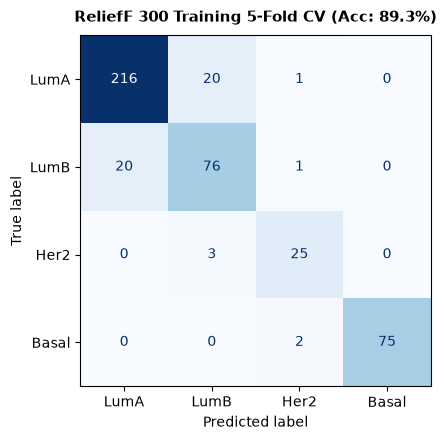


Generating sensitivity curve of CV Accuracy vs. k (ReliefF)...


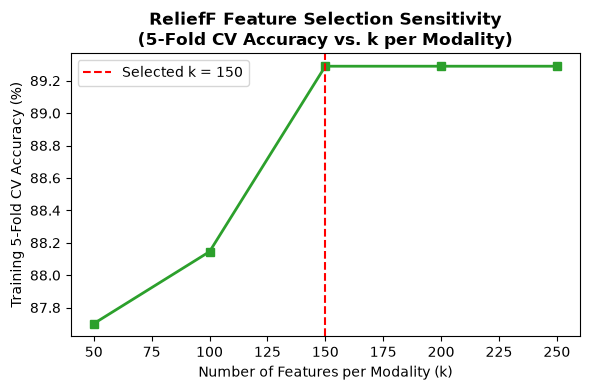


Note on ReliefF Comparison:
In Phase 4, we systematically compare Path A (ANOVA -> ReliefF -> mRMR) with Path B (direct ANOVA -> mRMR).
Both paths select 31 RNA and 19 Methylation biomarkers, with direct ANOVA -> mRMR providing
comparable/superior accuracy with lower computation time.


In [7]:
print('Validating ReliefF Feature Selection via 5-Fold CV on TRAINING DATA ONLY...')
print('(X_test is strictly preserved as a fresh holdout and NOT evaluated here)')

X_train_combined = np.hstack((X_train_rna_relief, X_train_meth_relief))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
y_tr_arr = np.asarray(y_train).ravel()

oof_preds = cross_val_predict(lda, X_train_combined, y_tr_arr, cv=cv)
cv_acc = accuracy_score(y_tr_arr, oof_preds)
target_names = ['LumA', 'LumB', 'Her2', 'Basal']

print(f'\n5-Fold Training CV Accuracy (Top 300 ReliefF Features): {cv_acc*100:.2f}%')
print(classification_report(y_tr_arr, oof_preds, target_names=target_names))

fig, ax = plot_confusion_matrix(y_train, oof_preds, target_names, f'ReliefF 300 Training 5-Fold CV (Acc: {cv_acc*100:.1f}%)')
plt.show()

# Sensitivity Analysis: Empirical justification of K=150 per modality
print('\nGenerating sensitivity curve of CV Accuracy vs. k (ReliefF)...')
k_candidates = [50, 100, 150, 200, 250]
k_accs = []
for k_c in k_candidates:
    s_r = X_train_rna[:, top_rna_indices_local[:k_c]]
    s_m = X_train_meth[:, top_meth_indices_local[:k_c]]
    s_comb = np.hstack((s_r, s_m))
    lda_k = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    fold_scores = [lda_k.fit(s_comb[t], y_tr_arr[t]).score(s_comb[v], y_tr_arr[v]) for t, v in cv.split(s_comb, y_tr_arr)]
    k_accs.append(np.mean(fold_scores))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_candidates, [s * 100 for s in k_accs], marker='s', color='#2ca02c', linewidth=2)
ax.axvline(x=150, color='red', linestyle='--', label='Selected k = 150')
ax.set_title('ReliefF Feature Selection Sensitivity\n(5-Fold CV Accuracy vs. k per Modality)', fontweight='bold')
ax.set_xlabel('Number of Features per Modality (k)')
ax.set_ylabel('Training 5-Fold CV Accuracy (%)')
ax.legend()
plt.tight_layout()
plt.show()

# Note on ReliefF in High Dimensions
print('\nNote on ReliefF Comparison:')
print('In Phase 4, we systematically compare Path A (ANOVA -> ReliefF -> mRMR) with Path B (direct ANOVA -> mRMR).')
print('Both paths select 31 RNA and 19 Methylation biomarkers, with direct ANOVA -> mRMR providing')
print('comparable/superior accuracy with lower computation time.')

## Saving Result
Saving for the Final Step (mRMR / Classification).

In [8]:
print('Saving ReliefF selected datasets to ../outputs/...')

save_object(X_train_rna_relief, 'X_train_rna_relief')
save_object(X_test_rna_relief,  'X_test_rna_relief')
save_object(final_rna_indices, 'feat_indices_rna_relief')
save_object(final_rna_names, 'feat_names_rna_relief')

save_object(X_train_meth_relief, 'X_train_meth_relief')
save_object(X_test_meth_relief,  'X_test_meth_relief')
save_object(final_meth_indices, 'feat_indices_meth_relief')
save_object(final_meth_names, 'feat_names_meth_relief')

save_object(y_train, 'y_train')
save_object(y_test,  'y_test')

print('\n🎉 Feature Selection Step 3 (ReliefF) Completed.')

Saving ReliefF selected datasets to '../outputs/'...
💾 Saved: ../outputs\X_train_rna_relief.npz (+ .pkl)
💾 Saved: ../outputs\X_test_rna_relief.npz (+ .pkl)
💾 Saved: ../outputs\feat_indices_rna_relief.npz (+ .pkl)
💾 Saved: ../outputs\feat_names_rna_relief.pkl
💾 Saved: ../outputs\X_train_meth_relief.npz (+ .pkl)
💾 Saved: ../outputs\X_test_meth_relief.npz (+ .pkl)
💾 Saved: ../outputs\feat_indices_meth_relief.npz (+ .pkl)
💾 Saved: ../outputs\feat_names_meth_relief.pkl
💾 Saved: ../outputs\y_train.parquet (+ .pkl)
💾 Saved: ../outputs\y_test.parquet (+ .pkl)

🎉 Feature Selection Step 3 (ReliefF) Completed.
